<a href="https://colab.research.google.com/github/JyotirmayaMishra/Job-Prediction-Analytics/blob/main/Job_Prediction_Analytics_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Title**

Job Prediction Analytics

**Objectives**

Outline the main goals of the 'Job Prediction Analytics' project based on the executed steps in the notebook. This includes data loading, cleaning, exploratory data analysis, feature engineering, model training, and performance evaluation.   

Present a comprehensive list of the project's objectives.

**Import** **Libraries**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

**import pandas as pd**: Imports the pandas library, which is essential for working with tabular data (like spreadsheets or SQL tables). It's commonly aliased as pd for convenience.

**import numpy as np:** Imports the NumPy library, which provides powerful numerical computing capabilities, especially for arrays and mathematical operations. It's commonly aliased as np.

**import matplotlib.pyplot as plt:** Imports the pyplot module from the Matplotlib library, which is a comprehensive library for creating static, interactive, and animated visualizations in Python. It's commonly aliased as plt.

**import seaborn as sns:** Imports the Seaborn library, which is built on top of Matplotlib and provides a high-level interface for drawing attractive and informative statistical graphics. It's commonly aliased as sns.

**ML**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from scipy.sparse import hstack

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

This code block imports several essential libraries and modules for machine learning tasks:

*   **`from sklearn.model_selection import train_test_split`**: Imports `train_test_split` from scikit-learn, used to split datasets into training and testing subsets.
*   **`from sklearn.preprocessing import LabelEncoder`**: Imports `LabelEncoder` from scikit-learn, used to encode categorical labels into numerical format.
*   **`from sklearn.feature_extraction.text import TfidfVectorizer`**: Imports `TfidfVectorizer` from scikit-learn, used to convert a collection of raw documents to a matrix of TF-IDF features.
*   **`from sklearn.metrics import accuracy_score`**: Imports `accuracy_score` from scikit-learn, used to calculate the accuracy of a classification model.
*   **`from sklearn.metrics import classification_report`**: Imports `classification_report` from scikit-learn, used to build a text report showing the main classification metrics.
*   **`from sklearn.metrics import confusion_matrix`**: Imports `confusion_matrix` from scikit-learn, used to evaluate the accuracy of a classification.
*   **`from scipy.sparse import hstack`**: Imports `hstack` from SciPy's sparse module, used to horizontally stack sparse matrices.
*   **`from xgboost import XGBClassifier`**: Imports `XGBClassifier` from XGBoost, which is an optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable.
*   **`import warnings`** and **`warnings.filterwarnings('ignore')`**: These lines are used to import the `warnings` module and then configure it to ignore all warnings during code execution, which can make the output cleaner, but should be used with caution in production environments.

**Load** **Dataset**

In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd

df = pd.read_csv("Job Predictions & Hr Analytics.csv")

Saving Job Predictions & Hr Analytics.csv to Job Predictions & Hr Analytics.csv


This code block handles uploading a CSV file to your Colab environment and then loading it into a pandas DataFrame:

*   **`from google.colab import files`**: Imports the `files` module, which is a utility provided by Google Colab to interact with your local filesystem, including uploading files.
*   **`uploaded = files.upload()`**: This command prompts you to select and upload a file from your local machine. Once the file is uploaded, it's stored in the Colab environment, and the `uploaded` variable (a dictionary) contains the file's name and its content.
*   **`import pandas as pd`**: Imports the pandas library, which is widely used for data manipulation and analysis in Python.
*   **`df = pd.read_csv("Job Predictions & Hr Analytics.csv")`**: This line uses pandas to read the uploaded CSV file (named "Job Predictions & Hr Analytics.csv") and stores its content in a DataFrame called `df`. A DataFrame is a powerful table-like data structure.

**Basic** **Understanding**

In [ ]:
df.head()

,segment,ability,motivation,communication,technical_strength,age,education_level,major,job,years_experience,summary,experience_desc
0,junior,-0.326104,1.383679,-0.848346,0.830218,37,bachelor,engineering,software_engineer,12.197163,Senior professional. Experienced in handling r...,Worked on multiple projects involving collabor...
1,mid,-0.668711,0.576427,0.272136,2.679227,18,bachelor,arts,software_engineer,1.746914,"With a bachelor degree in arts, I have contrib...",Handled responsibilities across several projec...
2,mid,-0.999829,-0.276967,-0.203322,1.079043,65,bachelor,NaN,data_analyst,19.719285,Senior professional. Bringing 19 years of expe...,NaN
3,senior,NaN,0.344694,-0.209641,NaN,18,high_school,business,data_analyst,3.000000,Senior professional. Experienced in handling r...,Handled responsibilities across several projec...
4,junior,-0.310706,1.353177,0.976049,-0.811274,18,bachelor,engineering,software_engineer,3.000000,Senior professional. With a bachelor degree in...,Worked on multiple projects involving collabor...


In [ ]:
df.shape

(306000, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306000 entries, 0 to 305999
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   segment             290674 non-null  object 
 1   ability             290864 non-null  float64
 2   motivation          290729 non-null  float64
 3   communication       290482 non-null  float64
 4   technical_strength  290934 non-null  float64
 5   age                 306000 non-null  int64  
 6   education_level     290844 non-null  object 
 7   major               290928 non-null  object 
 8   job                 290593 non-null  object 
 9   years_experience    299648 non-null  float64
 10  summary             260540 non-null  object 
 11  experience_desc     260104 non-null  object 
dtypes: float64(5), int64(1), object(6)
memory usage: 28.0+ MB


In [ ]:
df.describe()

,ability,motivation,communication,technical_strength,age,years_experience
count,290864.000000,290729.000000,290482.000000,290934.000000,306000.000000,299648.000000
mean,0.002173,-0.002061,0.001731,0.001608,36.433474,9.307245
std,1.001549,0.998648,1.002052,1.001408,18.601069,9.526004
min,-4.839440,-4.435243,-4.267254,-4.564401,18.000000,0.000000
25%,-0.673263,-0.674360,-0.675866,-0.673207,18.000000,3.000000
50%,0.001434,0.000290,0.002540,0.001288,31.000000,4.649277
75%,0.679752,0.673379,0.676890,0.677035,55.000000,13.620541
max,4.450909,4.486542,4.988726,4.885157,65.000000,48.920912


**Missing** **Values**

In [ ]:
df.isnull().sum()

,0
segment,15326
ability,15136
motivation,15271
communication,15518
technical_strength,15066
age,0
education_level,15156
major,15072
job,15407
years_experience,6352


**Data** **Cleaning**

In [ ]:
df = df.dropna()

This line of code, `df = df.dropna()`, is used for data cleaning. It removes all rows from the DataFrame `df` that contain *any* missing (NaN) values. This is a common step to ensure that subsequent analyses or model training are performed on complete data.

In [ ]:
df = df.drop_duplicates()

This line of code, `df = df.drop_duplicates()`, is another important step in data cleaning. It identifies and removes rows that are identical across all columns, ensuring that each observation in your DataFrame is unique. This helps prevent skewed analyses due to redundant data.

In [ ]:
df = df.reset_index(drop=True)

This line of code, `df = df.reset_index(drop=True)`, resets the DataFrame's index to a default integer sequence, effectively re-indexing the rows and discarding the old index.

**Verifying**

In [ ]:
print(df.shape)

(141269, 12)


In [ ]:
print(df.isnull().sum())

segment               0
ability               0
motivation            0
communication         0
technical_strength    0
age                   0
education_level       0
major                 0
job                   0
years_experience      0
summary               0
experience_desc       0
dtype: int64


**EDA**

**Job** **Distribution**

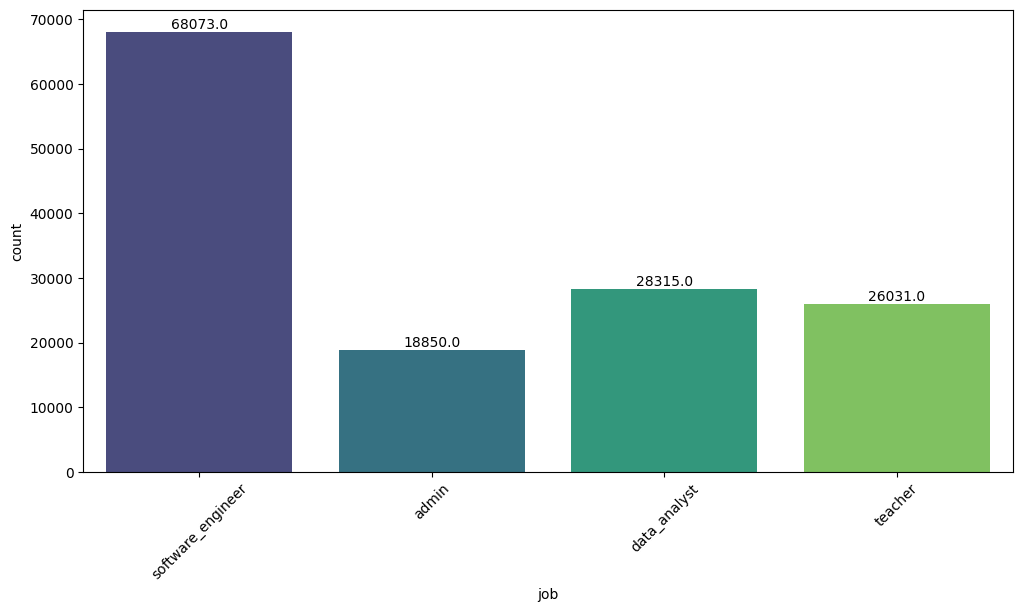

In [ ]:
plt.figure(figsize=(12,6))

ax = sns.countplot(x='job', data=df, palette='viridis')

plt.xticks(rotation=45)

# Add count figures to the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.show()

This code generates a count plot that visualizes the distribution of job roles (`x='job'`) from the `df` DataFrame. It sets the plot size, rotates the x-axis labels for readability, and importantly, adds the exact count figure on top of each bar using a loop and `ax.annotate`.

This code block generates a count plot to visualize the distribution of different job roles within your dataset. Let's break down what each line does:

*   **`plt.figure(figsize=(12,6))`**: This line creates a new figure for the plot and sets its size to 12 inches wide by 6 inches tall. This helps ensure the plot is appropriately sized for readability.
*   **`ax = sns.countplot(x='job', data=df, palette='viridis')`**: This is the core line for creating the count plot:
    *   `sns.countplot`: Calls the `countplot` function from the Seaborn library, which is used to show the counts of observations in each category using bars.
    *   `x='job'`: Specifies that the 'job' column from your DataFrame `df` should be used for the categories on the x-axis.
    *   `data=df`: Indicates that the data for the plot comes from the `df` DataFrame.
    *   `palette='viridis'`: Sets the color scheme for the bars to 'viridis', a perceptually uniform colormap.
*   **`plt.xticks(rotation=45)`**: This rotates the x-axis labels (the job titles) by 45 degrees. This is often necessary when category names are long to prevent them from overlapping and becoming unreadable.
*   **`for p in ax.patches:`**: This loop iterates through each bar (referred to as a 'patch') in the count plot.
    *   **`ax.annotate(f'{p.get_height()}', ...)`**: Inside the loop, this line adds a text annotation (the count number) on top of each bar.
        *   `f'{p.get_height()}'`: Gets the height of the current bar, which represents the count, and formats it as a string.
        *   `(p.get_x() + p.get_width() / 2., p.get_height())`: Calculates the x and y coordinates for placing the annotation. It centers the text horizontally on the bar and places it just above the bar.
        *   `ha='center'`, `va='center'`: Sets the horizontal and vertical alignment of the text to be centered.
        *   `fontsize=10`, `color='black'`: Sets the font size to 10 and the text color to black.
        *   `xytext=(0, 5)`, `textcoords='offset points'`: Adjusts the text position slightly (5 points upwards) relative to the calculated coordinates to prevent it from overlapping with the bar itself.
*   **`plt.show()`**: This command displays the generated plot.

**Education** **Level**

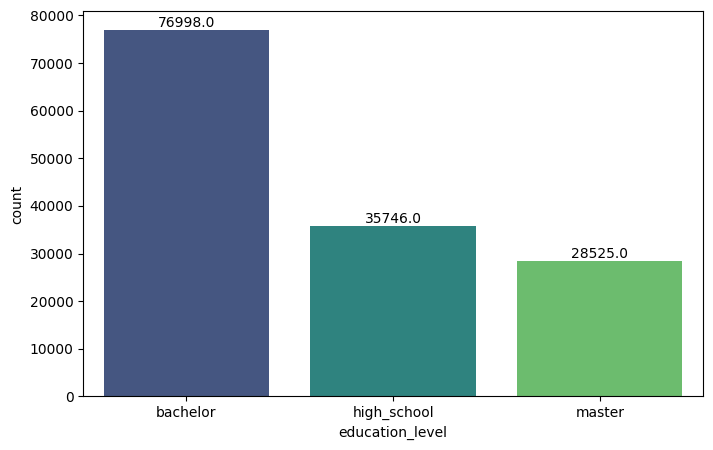

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.countplot(x='education_level', data=df, palette='viridis')

# Add count figures to the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.show()

This code generates a count plot visualizing the distribution of `education_level` from the `df` DataFrame. It sets the plot size, and adds the exact count figure on top of each bar for clarity.

**Age** **Distribution**



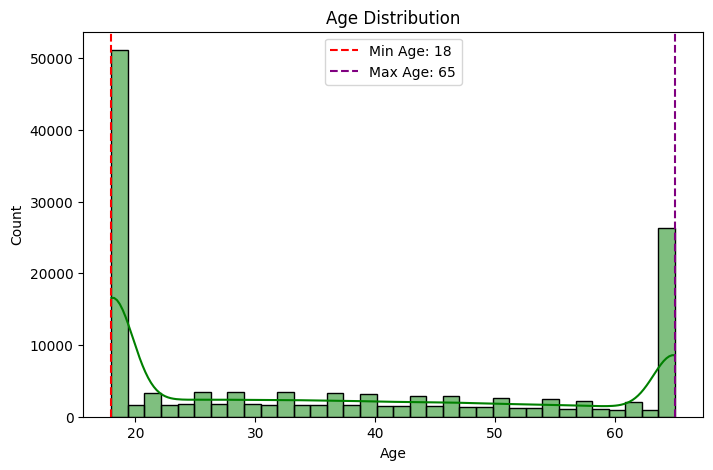

In [ ]:
plt.figure(figsize=(8,5))

# Plot the histogram with green bars and KDE
sns.histplot(df['age'], kde=True, color='green')

# Get min and max age
min_age = df['age'].min()
max_age = df['age'].max()

# Add vertical lines for min and max age
plt.axvline(min_age, color='red', linestyle='--', label=f'Min Age: {min_age}')
plt.axvline(max_age, color='purple', linestyle='--', label=f'Max Age: {max_age}')

# Add title and labels
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

# Add a legend for the min/max age lines
plt.legend()

plt.show()

This code generates an age distribution histogram for the `age` column in the `df` DataFrame. It displays a Kernel Density Estimate (KDE) curve and green bars. Additionally, it marks the minimum and maximum ages with red and purple dashed vertical lines, respectively, and includes a legend for these markers.

**Exprience** **Distrubtion**

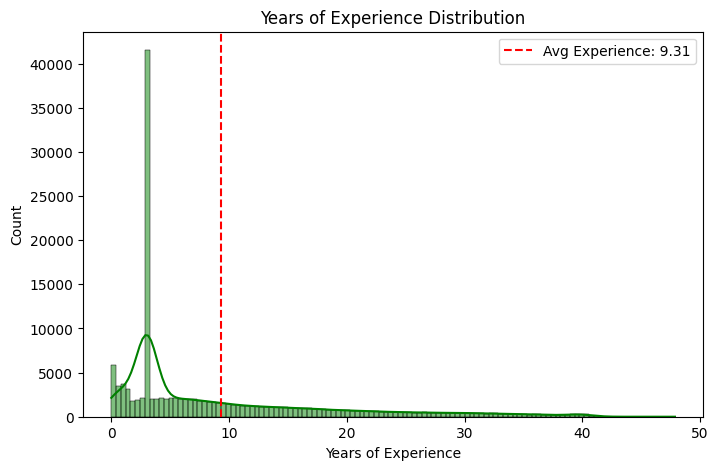

In [ ]:
plt.figure(figsize=(8,5))

# Plot the histogram with green bars and KDE
sns.histplot(df['years_experience'], kde=True, color='green')

# Calculate the average years of experience
avg_experience = df['years_experience'].mean()

# Add a vertical line for the average experience
plt.axvline(avg_experience, color='red', linestyle='--', label=f'Avg Experience: {avg_experience:.2f}')

# Add title and labels
plt.title('Years of Experience Distribution')
plt.xlabel('Years of Experience')
plt.ylabel('Count')

# Add a legend for the average experience line
plt.legend()

plt.show()

This code generates a green histogram with a KDE plot for 'years_experience', highlighting the average experience with a red dashed line.

**Correlation** **Heatmap**

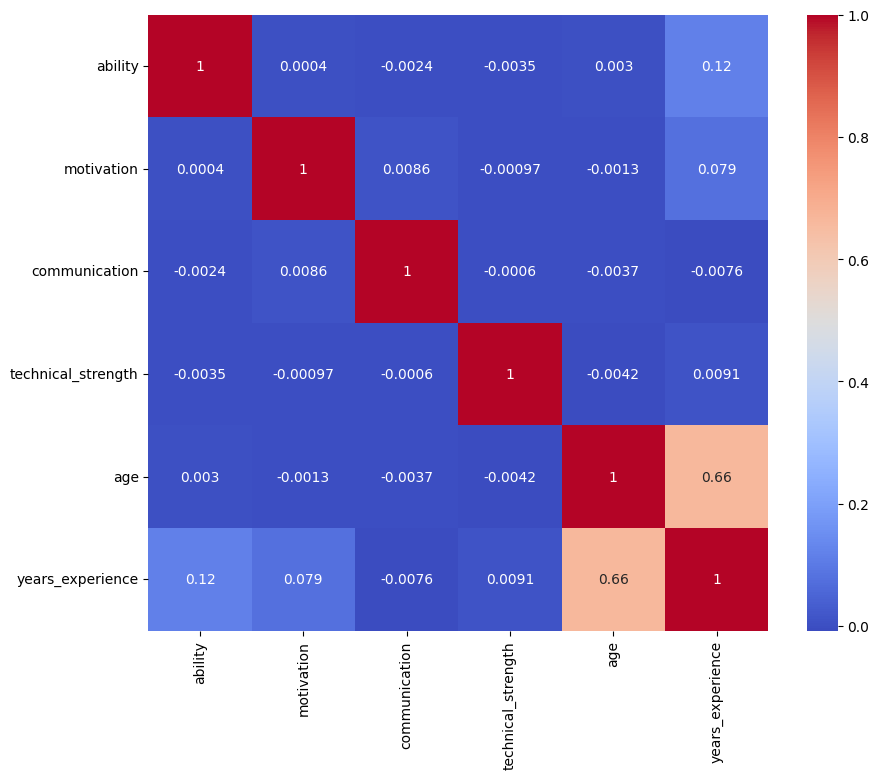

In [ ]:
numeric_df = df.select_dtypes(include='number')

corr = numeric_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.show()

This code block generates a correlation heatmap for the numerical columns in your DataFrame. Let's break down what each line does:

*   **`numeric_df = df.select_dtypes(include='number')`**: This line creates a new DataFrame called `numeric_df` by selecting only the columns from the original `df` DataFrame that have a numerical data type (e.g., `int64`, `float64`). This is important because correlation heatmaps are typically used for numerical variables.
*   **`corr = numeric_df.corr()`**: This calculates the pairwise correlation between all columns in the `numeric_df` DataFrame. The result is a correlation matrix, where each cell `(i, j)` represents the correlation between column `i` and column `j`.
*   **`plt.figure(figsize=(10,8))`**: This creates a new figure for the plot and sets its size to 10 inches wide by 8 inches tall.
*   **`sns.heatmap(corr, annot=True, cmap='coolwarm')`**: This is the core line for generating the heatmap:
    *   `sns.heatmap`: Calls the `heatmap` function from the Seaborn library.
    *   `corr`: Provides the correlation matrix calculated in the previous step as the data for the heatmap.
    *   `annot=True`: Displays the correlation coefficient values on the heatmap cells, making it easier to read the exact correlations.
    *   `cmap='coolwarm'`: Sets the color map for the heatmap to 'coolwarm'. This is a divergent colormap, where a neutral color (often white or light gray) is used for values near zero, and increasingly vibrant colors (e.g., cool for negative correlations, warm for positive correlations) are used for values further from zero.
*   **`plt.show()`**: This command displays the generated heatmap.

**Feauture** **Engineering**

**Create** **Text** **Feature**

In [ ]:
df['text'] = (
    df['summary'].fillna('') +
    ' ' +
    df['experience_desc'].fillna('')
)

This code block creates a new column named `text` in your DataFrame `df`. It combines the content of the `summary` and `experience_desc` columns. Here's how it works:

*   **`df['summary'].fillna('')`**: This part accesses the `summary` column. The `.fillna('')` method replaces any missing (NaN) values in this column with an empty string. This is important to ensure that when `summary` is concatenated with `experience_desc`, you don't end up with `NaN` in your new `text` column just because `summary` was missing.
*   **`df['experience_desc'].fillna('')`**: Similar to the above, this accesses the `experience_desc` column and replaces any missing values with an empty string.
*   **`+ ' ' +`**: The `+` operator concatenates strings. A space `' '` is added between the `summary` and `experience_desc` content to ensure there's a separation between the combined text.
*   **`df['text'] = ...`**: The result of this concatenation (the combined string from `summary` and `experience_desc`) is then assigned to a new column in the DataFrame called `text`. This new `text` column will contain a single string combining both pieces of information, which is often useful for natural language processing (NLP) tasks.

**Structured** **Features**

In [ ]:
structured_features = [
    'segment',
    'ability',
    'motivation',
    'communication',
    'technical_strength',
    'age',
    'education_level',
    'major',
    'years_experience'
]

This code block initializes a Python list named `structured_features`. This list contains a selection of column names from your DataFrame (`df`). These columns likely represent categorical or numerical features that are explicitly structured and will be used later in your machine learning pipeline for tasks such as feature engineering or model training.

**Create** **X** **Structured**

In [ ]:
X_structured = df[structured_features]

This line of code creates a new DataFrame called `X_structured`. It selects a subset of columns from your main DataFrame `df` based on the `structured_features` list you defined earlier. Essentially, it's extracting the structured features into their own DataFrame, which is a common step before applying machine learning models that expect a specific set of input features.

**Encode** **Categorical** **Features**

In [ ]:
for col in ['segment','education_level','major']:

    le = LabelEncoder()

    X_structured[col] = le.fit_transform(
        X_structured[col]
    )

This code iterates through the 'segment', 'education_level', and 'major' columns in `X_structured`. For each, it uses `LabelEncoder` to convert the categorical text values into numerical representations. This is a common preprocessing step to prepare categorical data for machine learning models.

**NLP** **Processing**

**TF**-**IDF** (Term Frequency-Inverse Document Frequency)

In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_text = tfidf.fit_transform(
    df['text']
)

This code initializes a `TfidfVectorizer` to transform the `text` column into a numerical TF-IDF matrix (`X_text`). It's configured to use up to 5000 features and remove English stop words, preparing the text data for machine learning models.

**Combine** **Features**

In [ ]:
X = hstack([
    X_structured,
    X_text
])

This code combines the structured features (`X_structured`) and the TF-IDF vectorized text features (`X_text`) into a single feature matrix `X` using `hstack`. This unified matrix `X` can then be used as input for training machine learning models.

**Target** **Encoding**

In [ ]:
target_encoder = LabelEncoder()

y = target_encoder.fit_transform(
    df['job']
)

This code uses `LabelEncoder` to convert the categorical string values in the `job` column of the DataFrame `df` into numerical labels. The resulting numerical array is stored in `y`. This is necessary because machine learning models typically require numerical input for the target variable.

**Train** **Text** **Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

This code splits the combined feature matrix `X` and the target variable `y` into training and testing sets using `train_test_split`.  
- `X_train`, `y_train`: Data for model training.  
- `X_test`, `y_test`: Data for model evaluation.  
- `test_size=0.20`: Allocates 20% of the data to the test set.  
- `random_state=42`: Ensures the split is reproducible.  
- `stratify=y`: Preserves the same proportion of target classes in both the training and testing sets, which is crucial for imbalanced datasets.

**XGBoost** **Model**

In [ ]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

This code initializes an `XGBClassifier` with various hyperparameters, setting up the configuration for the gradient boosting model.
- `n_estimators`: Defines the number of boosting rounds (trees) to build.
- `max_depth`: Sets the maximum depth for each tree, controlling model complexity.
- `learning_rate`: Determines the step size shrinkage to prevent overfitting.
- `subsample` and `colsample_bytree`: Control the fraction of samples and columns used for fitting each tree, respectively.
- `random_state`: Ensures reproducibility of the results.

After initialization, `model.fit(X_train, y_train)` trains the XGBoost model using the training features (`X_train`) and their corresponding target labels (`y_train`). This step is where the model learns the relationships in the data.

**Prediction**

In [ ]:
y_pred = model.predict(
    X_test
)

This code uses the already trained `XGBoost` model (`model`) to make predictions on the independent test dataset `X_test`. The output of this prediction, which represents the model's classification of job categories for the test data, is stored in the `y_pred` variable.

**Accuracy**

In [ ]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.9520421887166419


This code calculates the model's overall accuracy. `accuracy_score` measures the ratio of correctly predicted instances (`y_pred`) to the total number of instances in the true test labels (`y_test`). It provides a straightforward metric for evaluating the classification model's performance.

**Classification** **Report**

In [ ]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.95      0.91      0.93      3770
           1       0.94      0.92      0.93      5663
           2       0.95      0.98      0.97     13615
           3       0.97      0.95      0.96      5206

    accuracy                           0.95     28254
   macro avg       0.95      0.94      0.95     28254
weighted avg       0.95      0.95      0.95     28254



The `classification_report` provides detailed metrics for each predicted job category:
- **Precision**: How many of the predicted positives were actually positive.
- **Recall**: How many of the actual positives were correctly identified.
- **F1-Score**: The harmonic mean of precision and recall.
- **Support**: The number of actual occurrences of each class in the test set.

These metrics, along with overall accuracy, macro average, and weighted average, offer a comprehensive view of the model's performance across all classes.

**Confusion** **Matrix**

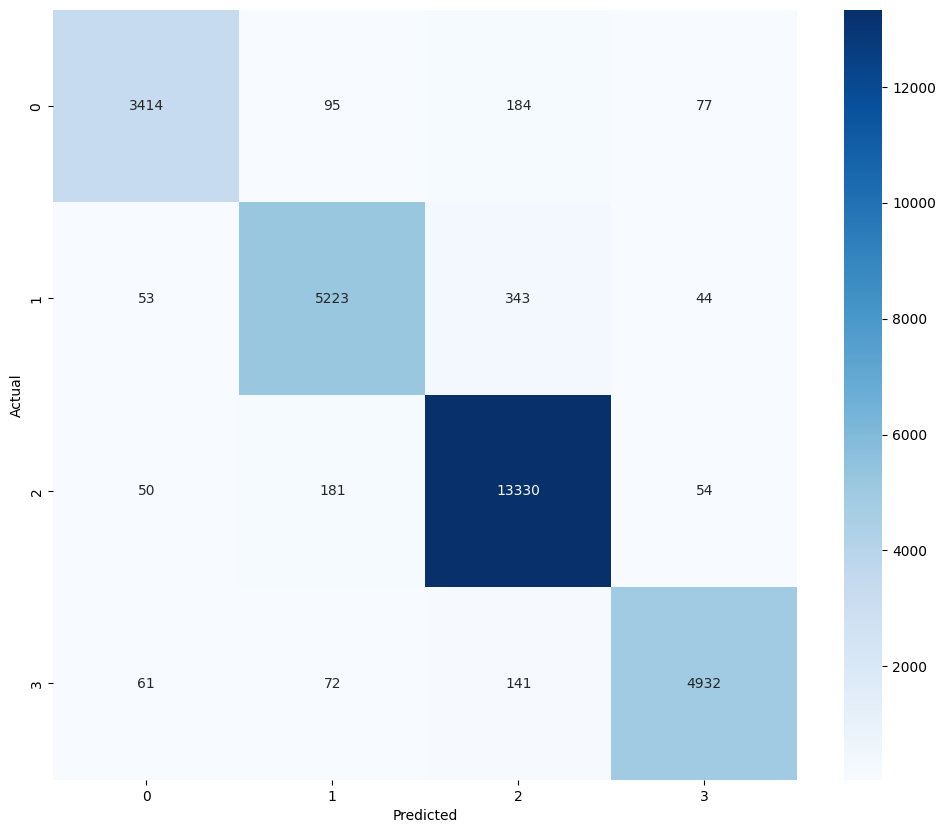

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

A **Confusion Matrix** is a table that is often used to describe the performance of a classification model (or "classifier") on a set of test data for which the true values are known. It allows the visualization of the performance of an algorithm.

### Components of the Confusion Matrix:

*   **True Positives (TP)**: The number of instances correctly predicted as the positive class. (e.g., model predicted 'software_engineer' and the actual job was 'software_engineer').
*   **True Negatives (TN)**: The number of instances correctly predicted as the negative class. (e.g., model predicted 'not software_engineer' and the actual job was 'not software_engineer').
*   **False Positives (FP)**: The number of instances incorrectly predicted as the positive class. (Type I error - e.g., model predicted 'software_engineer' but the actual job was 'data_analyst').
*   **False Negatives (FN)**: The number of instances incorrectly predicted as the negative class. (Type II error - e.g., model predicted 'data_analyst' but the actual job was 'software_engineer').


**Feature** **Importance**

In [ ]:
importance = pd.DataFrame({
    'Feature': structured_features,
    'Importance': model.feature_importances_[:len(structured_features)]
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

              Feature  Importance
7               major    0.001757
6     education_level    0.001180
3       communication    0.000708
4  technical_strength    0.000665
2          motivation    0.000477
1             ability    0.000459
8    years_experience    0.000276
5                 age    0.000222
0             segment    0.000209


This code calculates and displays the importance of each structured feature in the trained XGBoost model. It helps identify which features contributed most to the model's predictions, with higher importance values indicating greater influence.

**Feature** **Importance** **Chart**

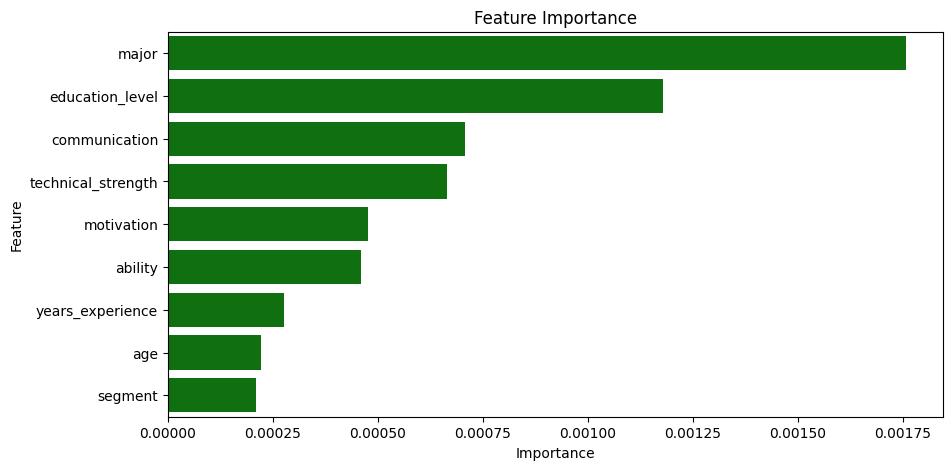

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature',
    color='green'
)

plt.title(
    "Feature Importance"
)

plt.show()